<a href="https://colab.research.google.com/github/King-Ju/Awesome-Profile-README-templates/blob/master/Simple_Exponential_Smoothing_(SES)_Holt%E2%80%99s_Linear_Trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
path = '/content/drive/MyDrive/Spare_Part_Forecast/rawdata.csv'
df = pd.read_csv(path,encoding='utf-8',na_values=['NA', '', 'NaN'])

In [43]:
df.columns

Index(['COMPANY_ID', 'YearMonth', 'SPARE_PART_ID', 'SPARE_PART_CODE',
       'SPARE_PART_NAME', 'NetUsage'],
      dtype='object')

In [44]:
df = df[['COMPANY_ID', 'YearMonth', 'SPARE_PART_CODE', 'NetUsage']]

In [8]:
print(f"Original DataFrame shape: {df.shape}")

df = df[df['NetUsage'] > 0]

print(f"New DataFrame shape after removing rows with NetUsage <= 0: {df.shape}")

Original DataFrame shape: (297072, 4)
New DataFrame shape after removing rows with NetUsage <= 0: (6040, 4)


In [45]:
# Convert 'YearMonth' to datetime objects
df['YearMonth'] = pd.to_datetime(df['YearMonth'])

# Extract year and month
df['Year'] = df['YearMonth'].dt.year
df['Month'] = df['YearMonth'].dt.month

# Number of unique years
num_years = df['Year'].nunique()
print(f"Number of years in the dataset: {num_years}")

# Number of unique months (distinct YearMonth values)
num_months = df['YearMonth'].nunique()
print(f"Number of unique YearMonths (months) in the dataset: {num_months}")

Number of years in the dataset: 4
Number of unique YearMonths (months) in the dataset: 36


In [46]:
# Count rows per month per year
rows_per_month_per_year = df.groupby(['Year', 'Month']).size().reset_index(name='Row Count')

print("Row count for each month per year:")
display(rows_per_month_per_year)

Row count for each month per year:


,Year,Month,Row Count
0,2023,5,8252
1,2023,6,8252
2,2023,7,8252
3,2023,8,8252
4,2023,9,8252
5,2023,10,8252
6,2023,11,8252
7,2023,12,8252
8,2024,1,8252
9,2024,2,8252


In [47]:
# Check for rows with any null values
null_rows = df[df.isnull().any(axis=1)]

if not null_rows.empty:
    print("Rows with null values:")
    display(null_rows)
else:
    print("No rows with null values found in the DataFrame.")

No rows with null values found in the DataFrame.


เรามาดูแถวที่ `SPARE_PART_NAME` ไม่ได้มีค่าที่ซ้ำกันเสมอไปกันค่ะ

In [48]:
# # Recalculate name_id_nunique as the previous cell was deleted.
# name_id_nunique = df.groupby('SPARE_PART_NAME')['SPARE_PART_ID'].nunique()

# # Filter for SPARE_PART_NAMEs that correspond to more than one SPARE_PART_ID
# non_unique_names = name_id_nunique[name_id_nunique > 1].index

# if not non_unique_names.empty:
#     print("Rows where SPARE_PART_NAME corresponds to multiple SPARE_PART_ID (i.e., not unique):")
#     display(df[df['SPARE_PART_NAME'].isin(non_unique_names)].sort_values(by='SPARE_PART_NAME'))
# else:
#     print("All SPARE_PART_NAME values uniquely identify a SPARE_PART_ID.")

### เตรียมข้อมูลสำหรับการสร้างโมเดลพยากรณ์แยกตาม `SPARE_PART_CODE`

In [49]:
# Aggregating NetUsage by SPARE_PART_CODE and YearMonth
df_part_monthly = df.groupby(['SPARE_PART_CODE', 'YearMonth'])['NetUsage'].sum().reset_index()
df_part_monthly = df_part_monthly.set_index('YearMonth')

print("Aggregated monthly NetUsage per SPARE_PART_CODE:")
display(df_part_monthly.head())
print(f"Number of records after aggregation: {len(df_part_monthly)}")

Aggregated monthly NetUsage per SPARE_PART_CODE:


,SPARE_PART_CODE,NetUsage
YearMonth,,
2023-05-01,SP-000-001,0
2023-06-01,SP-000-001,0
2023-07-01,SP-000-001,0
2023-08-01,SP-000-001,0
2023-09-01,SP-000-001,0


Number of records after aggregation: 297072


In [50]:
# Filter data for years 2023, 2024, 2025 as specified for training
df_filtered_part = df_part_monthly[(df_part_monthly.index.year >= 2023) & (df_part_monthly.index.year <= 2025)]

print("Filtered data for 2023-2025 per SPARE_PART_CODE:")
display(df_filtered_part.head())
display(df_filtered_part.tail())
print(f"Number of records after filtering: {len(df_filtered_part)}")

Filtered data for 2023-2025 per SPARE_PART_CODE:


,SPARE_PART_CODE,NetUsage
YearMonth,,
2023-05-01,SP-000-001,0
2023-06-01,SP-000-001,0
2023-07-01,SP-000-001,0
2023-08-01,SP-000-001,0
2023-09-01,SP-000-001,0


,SPARE_PART_CODE,NetUsage
YearMonth,,
2025-08-01,ZFree5,0
2025-09-01,ZFree5,0
2025-10-01,ZFree5,0
2025-11-01,ZFree5,0
2025-12-01,ZFree5,0


Number of records after filtering: 264064


### สร้างโมเดล Simple Exponential Smoothing (SES) และ Holt’s Linear Trend สำหรับแต่ละ `SPARE_PART_CODE`

In [51]:
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

unique_spare_parts = df_filtered_part['SPARE_PART_CODE'].unique()

# Dictionaries to store results
ses_results = {}
holt_results = {}

min_data_points = 5 # Minimum data points required for time series modeling

for part_code in unique_spare_parts:
    part_data = df_filtered_part[df_filtered_part['SPARE_PART_CODE'] == part_code]['NetUsage']

    if len(part_data) < min_data_points:
        print(f"Skipping {part_code}: Not enough data points ({len(part_data)} < {min_data_points}).")
        continue

    # Split data into 80% train and 20% test
    train_size = int(len(part_data) * 0.8)
    train_data = part_data.iloc[:train_size]
    test_data = part_data.iloc[train_size:]

    if len(test_data) == 0: # Ensure there's at least one point in the test set
        print(f"Skipping {part_code}: Test set is empty after splitting.")
        continue

    try:
        # Simple Exponential Smoothing (SES) Model
        fit_ses = SimpleExpSmoothing(train_data, initialization_method="estimated").fit()
        forecast_ses = fit_ses.forecast(len(test_data))
        rmse_ses = np.sqrt(mean_squared_error(test_data, forecast_ses))
        mae_ses = mean_absolute_error(test_data, forecast_ses)
        ses_results[part_code] = {'rmse': rmse_ses, 'mae': mae_ses, 'forecast': forecast_ses, 'train': train_data, 'test': test_data}

        # Holt's Linear Trend Model
        # Check if there is enough data for Holt's model (requires at least 2 observations for trend)
        if len(train_data) > 1:
            fit_holt = Holt(train_data, initialization_method="estimated").fit()
            forecast_holt = fit_holt.forecast(len(test_data))
            rmse_holt = np.sqrt(mean_squared_error(test_data, forecast_holt))
            mae_holt = mean_absolute_error(test_data, forecast_holt)
            holt_results[part_code] = {'rmse': rmse_holt, 'mae': mae_holt, 'forecast': forecast_holt, 'train': train_data, 'test': test_data}
        else:
            print(f"Not enough data for Holt's model for {part_code}.")

    except Exception as e:
        print(f"Error processing {part_code}: {e}")

print(f"Processed {len(ses_results)} spare parts with SES model.")
print(f"Processed {len(holt_results)} spare parts with Holt's model.")

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log

Processed 8252 spare parts with SES model.
Processed 8252 spare parts with Holt's model.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12

### สรุปผลการประเมินโมเดล

In [52]:
# Convert results to DataFrames for easier analysis
ses_df = pd.DataFrame.from_dict(ses_results, orient='index')
holt_df = pd.DataFrame.from_dict(holt_results, orient='index')

print("SES Model Performance Summary (Top 5 by RMSE):")
display(ses_df.sort_values(by='rmse').head()[['rmse', 'mae']])

print("\nHolt's Model Performance Summary (Top 5 by RMSE):")
display(holt_df.sort_values(by='rmse').head()[['rmse', 'mae']])

print("\nAverage RMSE and MAE across all SPARE_PART_CODEs:")
print(f"SES - Average RMSE: {ses_df['rmse'].mean():.2f}, Average MAE: {ses_df['mae'].mean():.2f}")
print(f"Holt's - Average RMSE: {holt_df['rmse'].mean():.2f}, Average MAE: {holt_df['mae'].mean():.2f}")

SES Model Performance Summary (Top 5 by RMSE):


,rmse,mae
SP-006-198,0.0,0.0
SP-006-216,0.0,0.0
SP-006-217,0.0,0.0
SP-006-218,0.0,0.0
SP-006-219,0.0,0.0



Holt's Model Performance Summary (Top 5 by RMSE):


,rmse,mae
SP-006-159,0.0,0.0
SP-006-177,0.0,0.0
SP-006-178,0.0,0.0
SP-006-179,0.0,0.0
SP-006-180,0.0,0.0



Average RMSE and MAE across all SPARE_PART_CODEs:
SES - Average RMSE: 2.66, Average MAE: 1.89
Holt's - Average RMSE: 2.75, Average MAE: 2.03


### แสดงผลการพยากรณ์สำหรับ `SPARE_PART_CODE` ตัวอย่าง

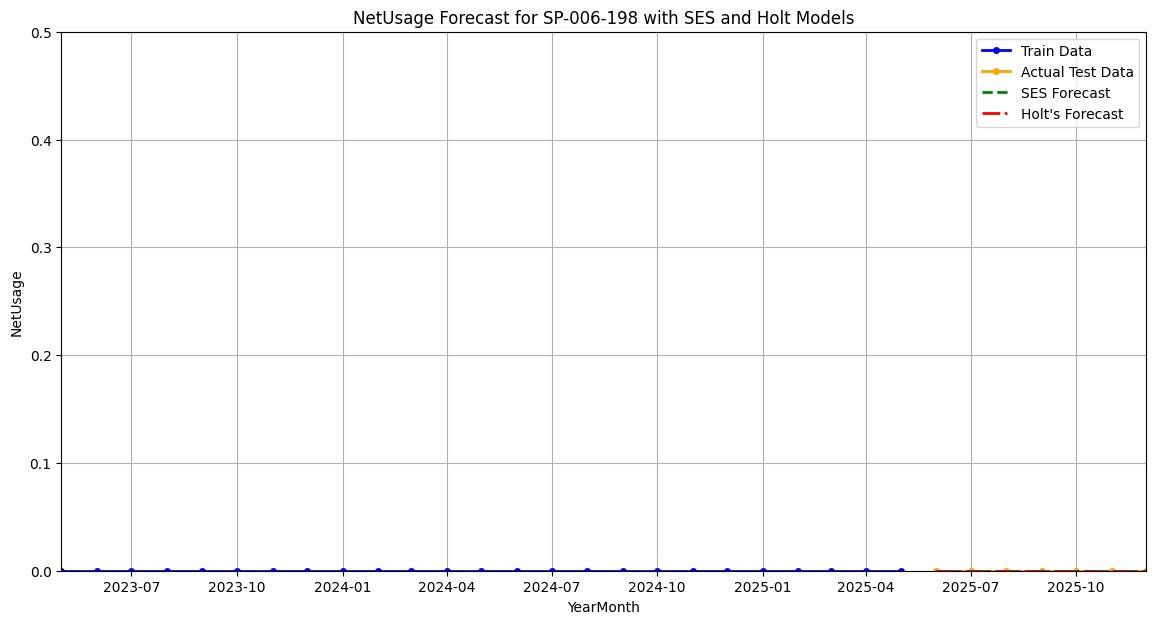

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Select a SPARE_PART_CODE to visualize (e.g., the one with the highest RMSE for SES)
if not ses_df.empty:
    example_part_code = ses_df.sort_values(by='rmse', ascending=True).index[0]
    example_ses_result = ses_results[example_part_code]
    example_holt_result = holt_results.get(example_part_code) # Use .get() in case Holt failed for this part

    plt.figure(figsize=(14, 7))
    plt.plot(example_ses_result['train'].index, example_ses_result['train'], label='Train Data', color='blue', linewidth=2, marker='o', markersize=4)
    plt.plot(example_ses_result['test'].index, example_ses_result['test'], label='Actual Test Data', color='orange', linewidth=2, marker='o', markersize=4)
    plt.plot(example_ses_result['forecast'].index, example_ses_result['forecast'], label='SES Forecast', color='green', linestyle='--', linewidth=2)

    if example_holt_result:
        plt.plot(example_holt_result['forecast'].index, example_holt_result['forecast'], label="Holt's Forecast", color='red', linestyle='-.', linewidth=2)

    plt.title(f'NetUsage Forecast for {example_part_code} with SES and Holt Models')
    plt.xlabel('YearMonth')
    plt.ylabel('NetUsage')
    plt.legend()
    plt.grid(True)

    # Set x-axis limits to only show the data range
    min_date = example_ses_result['train'].index.min()
    max_date = example_ses_result['test'].index.max()
    plt.xlim(min_date, max_date)

    # Calculate dynamic y-axis limits for more detail
    all_y_values = pd.concat([example_ses_result['train'], example_ses_result['test'], example_ses_result['forecast']])
    if example_holt_result:
        all_y_values = pd.concat([all_y_values, example_holt_result['forecast']])

    min_y = all_y_values.min()
    max_y = all_y_values.max()

    # Add a small buffer to the min and max for better visualization
    # Ensure min_y doesn't go below 0
    if min_y == max_y: # Handle cases where all values are identical
        y_buffer = 0.5 # Small fixed buffer
        min_y_lim = max(0, min_y - y_buffer)
        max_y_lim = max_y + y_buffer
    else:
        y_buffer = (max_y - min_y) * 0.1 # 10% buffer
        min_y_lim = max(0, min_y - y_buffer)
        max_y_lim = max_y + y_buffer

    plt.ylim(min_y_lim, max_y_lim)

    plt.show()
else:
    print("No spare parts were successfully modeled with SES to show an example.")

### พยากรณ์ `NetUsage` สำหรับปี 2026 ด้วยโมเดล SES (โมเดลที่ประสิทธิภาพดีที่สุด)

In [54]:
# Based on previous evaluation, SES had lower average RMSE and MAE.
# We will use the SES model to forecast for 2026.

forecast_2026_results = {}

# Retrain SES on the full 2023-2025 data for each part and forecast for 2026
for part_code in unique_spare_parts:
    part_data_2023_2025 = df_filtered_part[df_filtered_part['SPARE_PART_CODE'] == part_code]['NetUsage']

    if len(part_data_2023_2025) < min_data_points:
        # print(f"Skipping {part_code} for 2026 forecast: Not enough data points ({len(part_data_2023_2025)} < {min_data_points}).")
        continue

    try:
        # Train SES model on all available data for 2023-2025
        fit_ses_full_data = SimpleExpSmoothing(part_data_2023_2025, initialization_method="estimated").fit()

        # Forecast for the 12 months of 2026
        # Determine the start date for 2026 forecast
        last_date_in_data = part_data_2023_2025.index.max()
        # Calculate the number of steps to forecast until the end of 2026
        # The `start` parameter for forecast needs to be the next period after `last_date_in_data`
        # The `end` parameter for forecast needs to be the last period of 2026

        # Generate a date range for 2026 forecast
        forecast_start_date = last_date_in_data + pd.DateOffset(months=1)
        forecast_end_date = pd.Timestamp('2026-12-01') # End of 2026

        # Calculate the number of steps required to forecast until end of 2026
        # The forecast function takes a number of steps, not a date range
        # So we need to calculate how many months are between forecast_start_date and forecast_end_date inclusive
        num_forecast_steps = (forecast_end_date.year - forecast_start_date.year) * 12 + \
                             (forecast_end_date.month - forecast_start_date.month) + 1

        forecast_2026 = fit_ses_full_data.forecast(steps=num_forecast_steps)

        # Assign a proper DatetimeIndex to the forecast series for merging later
        forecast_index = pd.date_range(start=forecast_start_date, periods=num_forecast_steps, freq='MS')
        forecast_2026.index = forecast_index

        forecast_2026_results[part_code] = forecast_2026.rename('Forecasted_NetUsage') # Rename for clarity

    except Exception as e:
        print(f"Error processing {part_code} for 2026 forecast: {e}")

print(f"Generated 2026 forecasts for {len(forecast_2026_results)} spare parts using SES model.")

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1380: RuntimeWarning: divide by zero encountered in log
  aic = self.nobs * np.log(sse / self.nobs) + k * 2
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:1387: RuntimeWarning: divide by zero encountered in log
  bic = self.nobs * np.log(sse / self.nobs) + k * np.log(self.nobs)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self

Generated 2026 forecasts for 8252 spare parts using SES model.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### ตารางเปรียบเทียบค่าจริงและการพยากรณ์สำหรับปี 2026

In [55]:
# Extract actual 2026 data from the original df_part_monthly
actual_2026_data = df_part_monthly[df_part_monthly.index.year == 2026].reset_index()
actual_2026_data = actual_2026_data.rename(columns={'NetUsage': 'Actual_NetUsage'})

# Create a list to store comparison DataFrames for each part
comparison_dfs = []

for part_code, forecast_series in forecast_2026_results.items():
    # Get actual data for the current part in 2026
    actual_part_2026 = actual_2026_data[actual_2026_data['SPARE_PART_CODE'] == part_code]
    actual_part_2026 = actual_part_2026.set_index('YearMonth')

    # Combine actual and forecasted values for this part
    combined_df = pd.DataFrame({
        'Actual_NetUsage': actual_part_2026['Actual_NetUsage'],
        'Forecasted_NetUsage': forecast_series
    })

    # Ensure both series have the same index for accurate merging/calculation
    # Fill NaN for actuals where there is no data, or forecasts if somehow they don't align
    combined_df = combined_df.reindex(forecast_series.index) # Use forecast index as base
    combined_df['Actual_NetUsage'] = actual_part_2026['Actual_NetUsage'] # Re-assign to match forecast index

    # Calculate difference and percentage difference
    combined_df['Difference'] = combined_df['Forecasted_NetUsage'] - combined_df['Actual_NetUsage']
    combined_df['Percentage_Difference'] = (combined_df['Difference'] / combined_df['Actual_NetUsage']) * 100

    combined_df['SPARE_PART_CODE'] = part_code

    # Reset index and rename the 'index' column to 'YearMonth'
    comparison_dfs.append(combined_df.reset_index().rename(columns={'index': 'YearMonth'}))

if comparison_dfs:
    final_comparison_df = pd.concat(comparison_dfs, ignore_index=True)
    final_comparison_df = final_comparison_df.set_index(['SPARE_PART_CODE', 'YearMonth'])
    print("Comparison Table for 2026 Forecasts:")
    display(final_comparison_df)
else:
    print("No 2026 forecasts were generated or no actual 2026 data found to create a comparison table.")

Comparison Table for 2026 Forecasts:


Actual_NetUsage  Forecasted_NetUsage  Difference  \
SPARE_PART_CODE YearMonth                                                      
SP-000-001      2026-01-01              0.0              0.00000         0.0   
                2026-02-01              0.0              0.00000         0.0   
                2026-03-01              0.0              0.00000         0.0   
                2026-04-01              0.0              0.00000         0.0   
                2026-05-01              NaN              0.00000         NaN   
...                                     ...                  ...         ...   
ZFree5          2026-08-01              NaN              0.09375         NaN   
                2026-09-01              NaN              0.09375         NaN   
                2026-10-01              NaN              0.09375         NaN   
                2026-11-01              NaN              0.09375         NaN   
                2026-12-01              NaN              0.09375         NaN   

                            Percentage_Difference  
SPARE_PART_CODE YearMonth                          
SP-000-001      2026-01-01                    NaN  
                2026-02-01                    NaN  
                2026-03-01                    NaN  
                2026-04-01                    NaN  
                2026-05-01                    NaN  
...                                           ...  
ZFree5          2026-08-01                    NaN  
                2026-09-01                    NaN  
                2026-10-01                    NaN  
                2026-11-01                    NaN  
                2026-12-01                    NaN  

[99024 rows x 4 columns]

In [ ]:
final_comparison_df

### แสดงผล `final_comparison_df` เฉพาะแถวที่ไม่มีค่า `NaN` ในคอลัมน์เปรียบเทียบ

In [56]:
# Filter out rows where any of the comparison columns are NaN
# Note: If 'Actual_NetUsage' was explicitly set to NaN previously, this will result in an empty DataFrame
# unless 'final_comparison_df_modified' is intended here.
# Assuming the user wants to filter the 'final_comparison_df' as it was before setting Actual_NetUsage to NaN globally.

# Let's re-run the final_comparison_df creation to ensure it's not the 'modified' one
# Extract actual 2026 data from the original df_part_monthly
actual_2026_data = df_part_monthly[df_part_monthly.index.year == 2026].reset_index()
actual_2026_data = actual_2026_data.rename(columns={'NetUsage': 'Actual_NetUsage'})

# Create a list to store comparison DataFrames for each part
comparison_dfs_filtered = []

for part_code, forecast_series in forecast_2026_results.items():
    # Get actual data for the current part in 2026
    actual_part_2026 = actual_2026_data[actual_2026_data['SPARE_PART_CODE'] == part_code]
    actual_part_2026 = actual_part_2026.set_index('YearMonth')

    # Combine actual and forecasted values for this part
    combined_df_filtered = pd.DataFrame({
        'Actual_NetUsage': actual_part_2026['Actual_NetUsage'],
        'Forecasted_NetUsage': forecast_series
    })

    # Ensure both series have the same index for accurate merging/calculation
    combined_df_filtered = combined_df_filtered.reindex(forecast_series.index) # Use forecast index as base
    combined_df_filtered['Actual_NetUsage'] = actual_part_2026['Actual_NetUsage'] # Re-assign to match forecast index

    # Calculate difference and percentage difference
    combined_df_filtered['Difference'] = combined_df_filtered['Forecasted_NetUsage'] - combined_df_filtered['Actual_NetUsage']
    combined_df_filtered['Percentage_Difference'] = (combined_df_filtered['Difference'] / combined_df_filtered['Actual_NetUsage']) * 100

    combined_df_filtered['SPARE_PART_CODE'] = part_code

    comparison_dfs_filtered.append(combined_df_filtered.reset_index().rename(columns={'index': 'YearMonth'}))

if comparison_dfs_filtered:
    final_comparison_df_filtered = pd.concat(comparison_dfs_filtered, ignore_index=True)
    final_comparison_df_filtered = final_comparison_df_filtered.set_index(['SPARE_PART_CODE', 'YearMonth'])

    # Filter rows where Actual_NetUsage is not NaN
    filtered_df = final_comparison_df_filtered.dropna(subset=['Actual_NetUsage'])

    print("Comparison Table (filtered to show only non-NaN Actual_NetUsage):")
    display(filtered_df)
else:
    print("No 2026 forecasts were generated or no actual 2026 data found to create a comparison table for filtering.")

Comparison Table (filtered to show only non-NaN Actual_NetUsage):


Actual_NetUsage  Forecasted_NetUsage  Difference  \
SPARE_PART_CODE YearMonth                                                      
SP-000-001      2026-01-01              0.0              0.00000     0.00000   
                2026-02-01              0.0              0.00000     0.00000   
                2026-03-01              0.0              0.00000     0.00000   
                2026-04-01              0.0              0.00000     0.00000   
SP-000-002      2026-01-01              0.0              0.00000     0.00000   
...                                     ...                  ...         ...   
ZFree4          2026-04-01              0.0              0.03125     0.03125   
ZFree5          2026-01-01              0.0              0.09375     0.09375   
                2026-02-01              0.0              0.09375     0.09375   
                2026-03-01              0.0              0.09375     0.09375   
                2026-04-01              0.0              0.09375     0.09375   

                            Percentage_Difference  
SPARE_PART_CODE YearMonth                          
SP-000-001      2026-01-01                    NaN  
                2026-02-01                    NaN  
                2026-03-01                    NaN  
                2026-04-01                    NaN  
SP-000-002      2026-01-01                    NaN  
...                                           ...  
ZFree4          2026-04-01                    inf  
ZFree5          2026-01-01                    inf  
                2026-02-01                    inf  
                2026-03-01                    inf  
                2026-04-01                    inf  

[33008 rows x 4 columns]

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### คำนวณค่าเฉลี่ยของผลต่าง (Difference) และผลต่างเป็นเปอร์เซ็นต์ (Percentage Difference) สำหรับแต่ละ `SPARE_PART_CODE`

In [57]:
if 'filtered_df' in locals():
    # Calculate the average difference and percentage difference for each SPARE_PART_CODE
    average_diff_per_part = filtered_df.groupby('SPARE_PART_CODE')[['Difference', 'Percentage_Difference']].mean()

    print("Average Difference and Percentage Difference per SPARE_PART_CODE (only for months with actual data):")
    display(average_diff_per_part)
else:
    print("The 'filtered_df' DataFrame is not available. Please ensure the previous cells have been run.")

Average Difference and Percentage Difference per SPARE_PART_CODE (only for months with actual data):


,Difference,Percentage_Difference
SPARE_PART_CODE,,
SP-000-001,0.00000,NaN
SP-000-002,0.00000,NaN
SP-000-003,0.00000,NaN
SP-000-004,0.00000,NaN
SP-000-005,0.00000,NaN
...,...,...
ZFree 1,0.00000,NaN
ZFree2,0.00000,NaN
ZFree3,0.12500,inf


In [ ]:
# output_csv_path = '/content/drive/MyDrive/non_unique_spare_part_names.csv'
# df[df['SPARE_PART_NAME'].isin(non_unique_names)].to_csv(output_csv_path, index=False, encoding='utf-8')
# print(f"Data successfully saved to {output_csv_path}")